### noise=5%

In [ ]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:2" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix
CUDA_LAUNCH_BLOCKING=1

def f_circle(x,x_left,x_right,y_below,y_upper,center,r):
    # Compute r_y = sqrt((x1 - y1)^2 + (x2 - y2)^2 + (x3 - y3)^2)
    r_y = np.linalg.norm(x - center, axis=-1)
    # Apply the piecewise function
    f_y_values = np.where(r_y < r , 1.0, 0.0)
    return f_y_values

def f_rec(x,x_left,x_right,y_below,y_upper,center,r):
    cond= (x[:,0]>=x_left) & (x[:,0]<=x_right) & (x[:,1]>=y_below) & (x[:,1]<=y_upper)
    return cond*1

def ana_S(x,x_left,x_right,y_below,y_upper,center,r): #x为数据，a，b均为中心点
    return f_circle(x,x_left,x_right,y_below,y_upper,center,r)-f_rec(x,x_left,x_right,y_below,y_upper,center,r)


cuda:2


In [2]:
import copy
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89]
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=10
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.71,0.5])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=0
S_int_true1, F_mea_b1, F_mea_db_x11, F_mea_db_x21 = generate_data2.boundary_data_rec(kk, number_gene,points_b, f_rec, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true2, F_mea_b2, F_mea_db_x12, F_mea_db_x22 = generate_data2.boundary_data_circle(kk, number_gene,points_b, f_circle, x_left,x_right,y_below,y_upper, center_true, r_true, eps,mea,batch_number_rec_mea,device,cupy_device)
F_mea_b_05 = -F_mea_b1 + F_mea_b2
F_mea_db_x1_05 = -F_mea_db_x11 + F_mea_db_x12
F_mea_db_x2_05 = -F_mea_db_x21 + F_mea_db_x22
F_05=org_m.F(F_mea_b_05,F_mea_db_x1_05,F_mea_db_x2_05)

cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [3]:
M=1600
af="Tanh"   #先用tanh
R_m=20
cupy_device= 0
models = net_2D_fix2.pre_define(Nx,Ny,M,R_m,af,tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],[],device)

In [ ]:
models=torch.load("./Noise/noise=5%/models0_33_1600_7407_0.0001.pth")

In [ ]:
import pickle

with open("./Noise/noise=5%/cells_store_last.pkl", "rb") as f:
    cells_store_last = pickle.load(f)
g_S=np.load("./Noise/noise=5%/g_S.npy")
S_num_store=np.load("./Noise/noise=5%/S_num_store.npy")

Number of detected clusters: 2
Cluster 0: AR=1.98
  Res_Rect=0.109 vs Res_Ellip=0.122
  -> Winner: Rectangle
  CV of S_num: 0.185
Cluster 0: Lx=0.203, Ly=0.403, AR=1.98
  -> Decision: Rectangle (Sigmoid)
  Center: (0.385, 0.497)
    W: 0.203, H: 0.403
    Rect Residual: 0.1090, Ellip Residual: 0.1223
    Aspect Ratio: 1.984
    Curvature - Std: 0.3087, Mean: 0.0967, Peak Ratio: 14.62
Cluster 1: AR=1.01
  Res_Rect=0.097 vs Res_Ellip=0.026
  -> Winner: Circle
  CV of S_num: 0.193
Cluster 1: Lx=0.390, Ly=0.393, AR=1.01
  -> Decision: Circle (Sigmoid)
  Center: (0.714, 0.496)
    Radius: 0.204
    Rect Residual: 0.0967, Ellip Residual: 0.0264
    Aspect Ratio: 1.009
    Curvature - Std: 0.3865, Mean: 0.1628, Peak Ratio: 8.69


/mnt/store/hxw-y23/AMain/Bound_detect.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Number of detected clusters: 2
Cluster 0: AR=1.97
  Res_Rect=0.049 vs Res_Ellip=0.144
  -> Winner: Rectangle
  CV of S_num: 0.197
Cluster 0: Lx=0.203, Ly=0.400, AR=1.97
  -> Decision: Rectangle (Sigmoid)
  Center: (0.385, 0.505)
    W: 0.203, H: 0.400
    Rect Residual: 0.0486, Ellip Residual: 0.1437
    Aspect Ratio: 1.967
    Curvature - Std: 0.2959, Mean: 0.0878, Peak Ratio: 16.10
Cluster 1: AR=1.01
  Res_Rect=0.096 vs Res_Ellip=0.025
  -> Winner: Circle
  CV of S_num: 0.202
Cluster 1: Lx=0.390, Ly=0.393, AR=1.01
  -> Decision: Circle (Sigmoid)
  Center: (0.715, 0.498)
    Radius: 0.203
    Rect Residual: 0.0957, Ellip Residual: 0.0247
    Aspect Ratio: 1.009
    Curvature - Std: 0.3865, Mean: 0.1628, Peak Ratio: 8.69


/mnt/store/hxw-y23/AMain/Bound_detect.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Number of detected clusters: 2
Cluster 0: AR=1.97
  Res_Rect=0.044 vs Res_Ellip=0.141
  -> Winner: Rectangle
  CV of S_num: 0.206
Cluster 0: Lx=0.203, Ly=0.400, AR=1.97
  -> Decision: Rectangle (Sigmoid)
  Center: (0.387, 0.509)
    W: 0.203, H: 0.400
    Rect Residual: 0.0437, Ellip Residual: 0.1412
    Aspect Ratio: 1.967
    Curvature - Std: 0.2959, Mean: 0.0878, Peak Ratio: 16.10
Cluster 1: AR=1.01
  Res_Rect=0.097 vs Res_Ellip=0.030
  -> Winner: Circle
  CV of S_num: 0.209
Cluster 1: Lx=0.390, Ly=0.393, AR=1.01
  -> Decision: Circle (Sigmoid)
  Center: (0.718, 0.499)
    Radius: 0.204
    Rect Residual: 0.0970, Ellip Residual: 0.0298
    Aspect Ratio: 1.007
    Curvature - Std: 0.3865, Mean: 0.1628, Peak Ratio: 8.69


...

/mnt/store/hxw-y23/AMain/Bound_detect.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Number of detected clusters: 2
Cluster 0: AR=1.85
  Res_Rect=0.043 vs Res_Ellip=0.137
  -> Winner: Rectangle
  CV of S_num: 0.360
Cluster 0: Lx=0.227, Ly=0.420, AR=1.85
  -> Decision: Rectangle (Sigmoid)
  Center: (0.387, 0.509)
    W: 0.227, H: 0.420
    Rect Residual: 0.0428, Ellip Residual: 0.1371
    Aspect Ratio: 1.853
    Curvature - Std: 0.3063, Mean: 0.0949, Peak Ratio: 14.90
Cluster 1: AR=1.02
  Res_Rect=0.094 vs Res_Ellip=0.027
  -> Winner: Circle
  CV of S_num: 0.357
Cluster 1: Lx=0.403, Ly=0.413, AR=1.02
  -> Decision: Circle (Sigmoid)
  Center: (0.715, 0.497)
    Radius: 0.211
    Rect Residual: 0.0939, Ellip Residual: 0.0273
    Aspect Ratio: 1.025
    Curvature - Std: 0.3951, Mean: 0.1718, Peak Ratio: 8.23


/mnt/store/hxw-y23/AMain/Bound_detect.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Number of detected clusters: 2
Cluster 0: AR=1.85
  Res_Rect=0.042 vs Res_Ellip=0.137
  -> Winner: Rectangle
  CV of S_num: 0.359
Cluster 0: Lx=0.227, Ly=0.420, AR=1.85
  -> Decision: Rectangle (Sigmoid)
  Center: (0.388, 0.510)
    W: 0.227, H: 0.420
    Rect Residual: 0.0423, Ellip Residual: 0.1369
    Aspect Ratio: 1.853
    Curvature - Std: 0.3063, Mean: 0.0949, Peak Ratio: 14.90
Cluster 1: AR=1.03
  Res_Rect=0.091 vs Res_Ellip=0.032
  -> Winner: Circle
  CV of S_num: 0.357
Cluster 1: Lx=0.400, Ly=0.412, AR=1.03
  -> Decision: Circle (Sigmoid)
  Center: (0.714, 0.497)
    Radius: 0.210
    Rect Residual: 0.0915, Ellip Residual: 0.0315
    Aspect Ratio: 1.030
    Curvature - Std: 0.3951, Mean: 0.1718, Peak Ratio: 8.23


/mnt/store/hxw-y23/AMain/Bound_detect.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


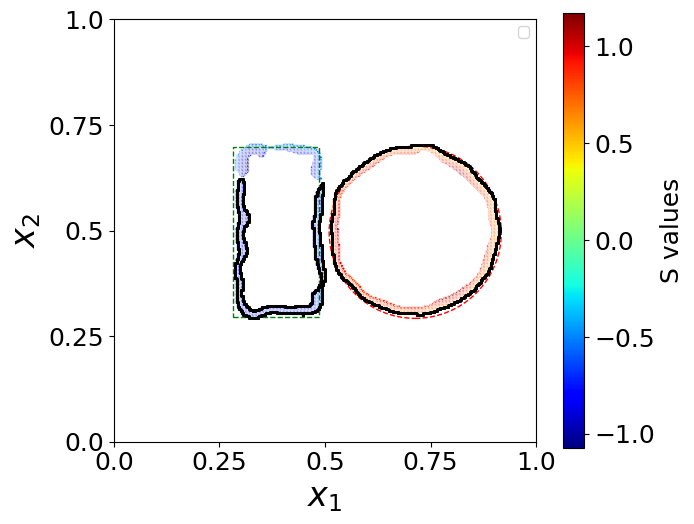

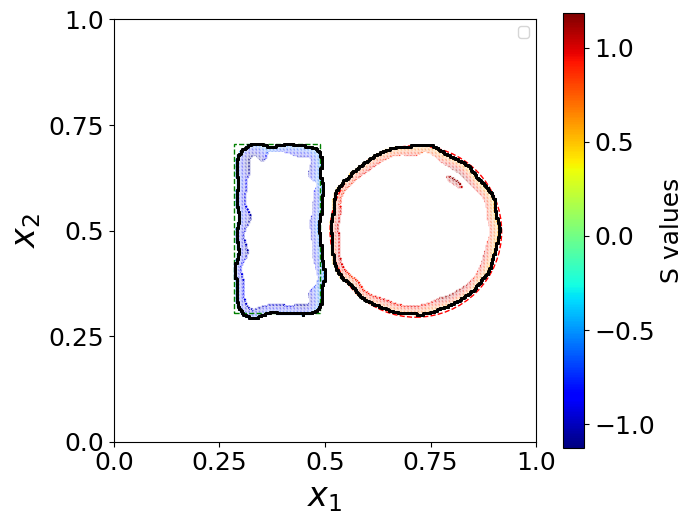

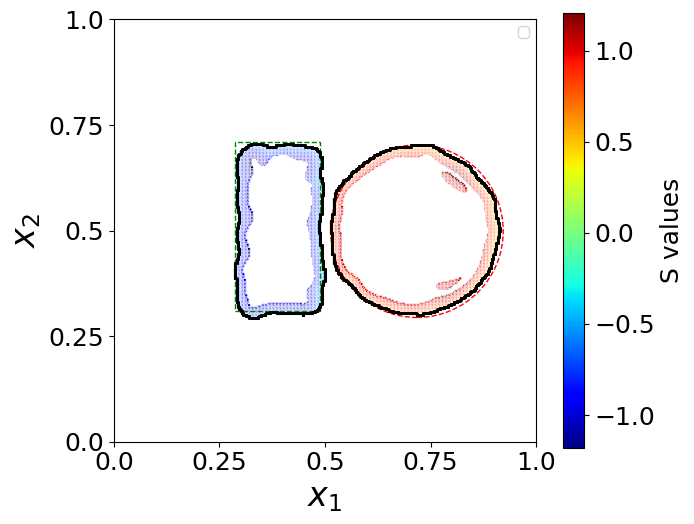

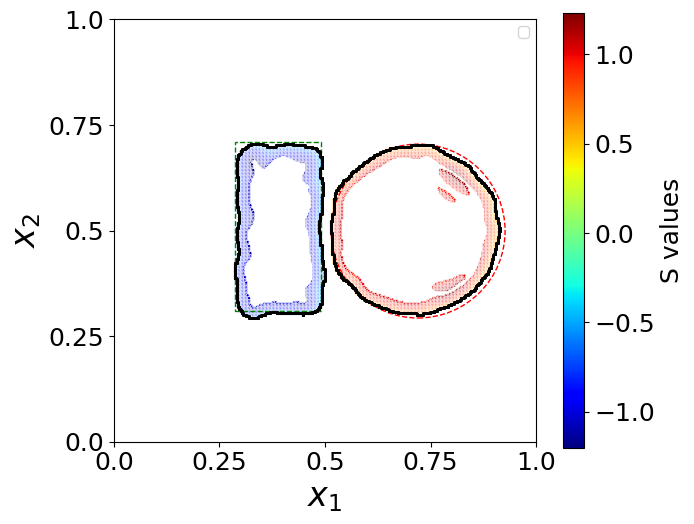

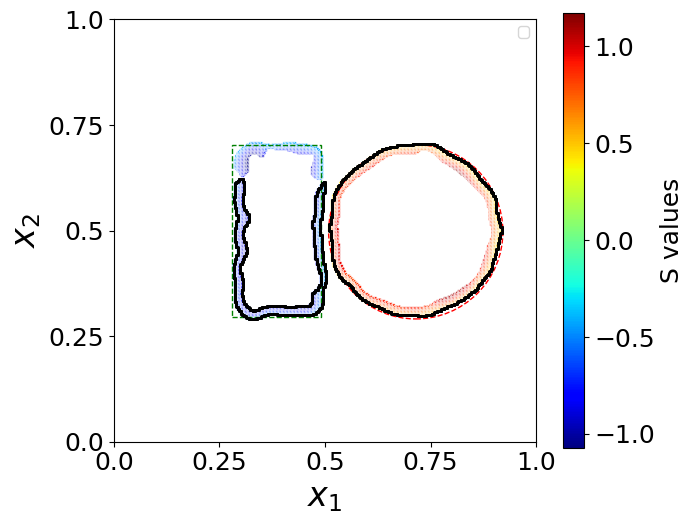

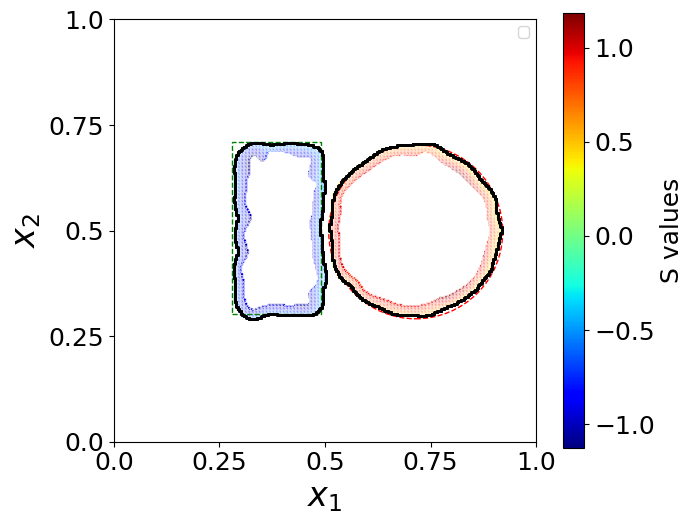

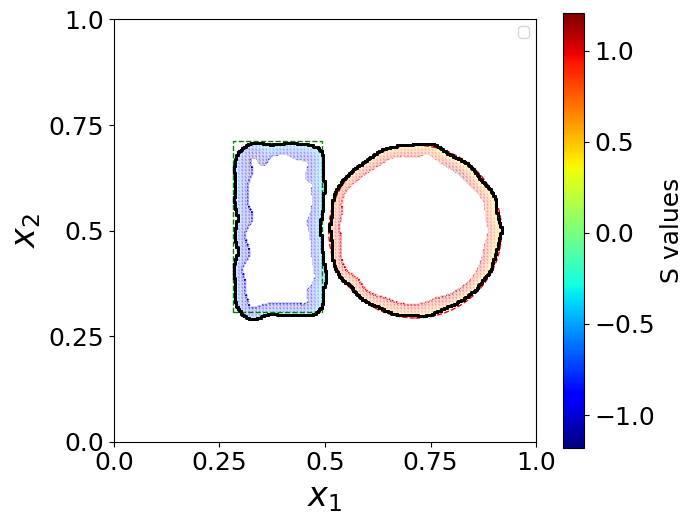

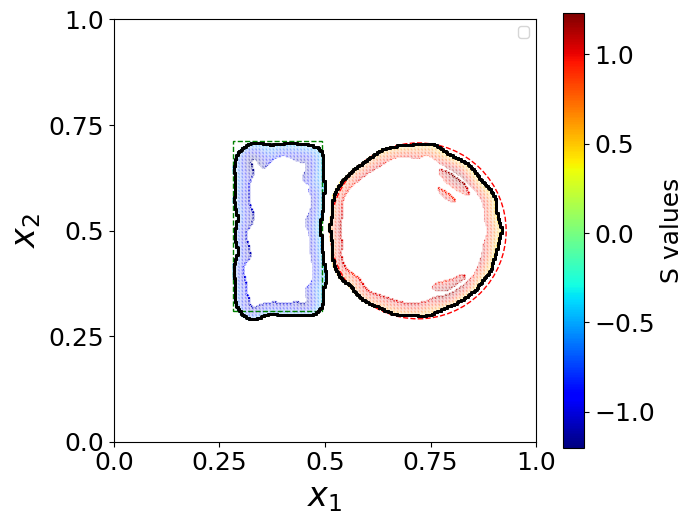

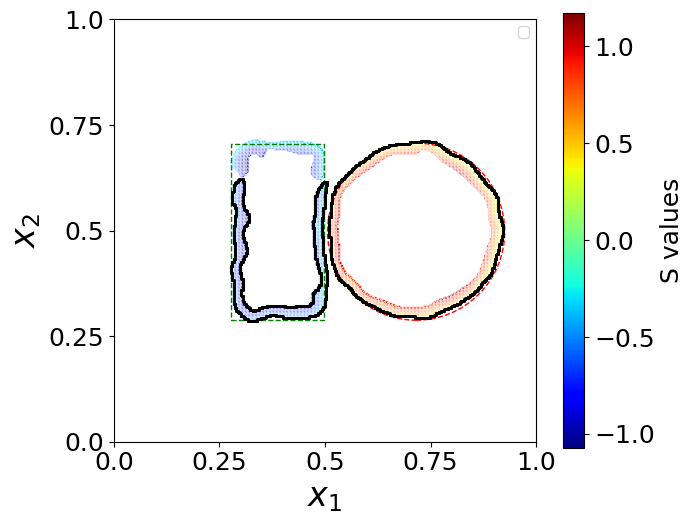

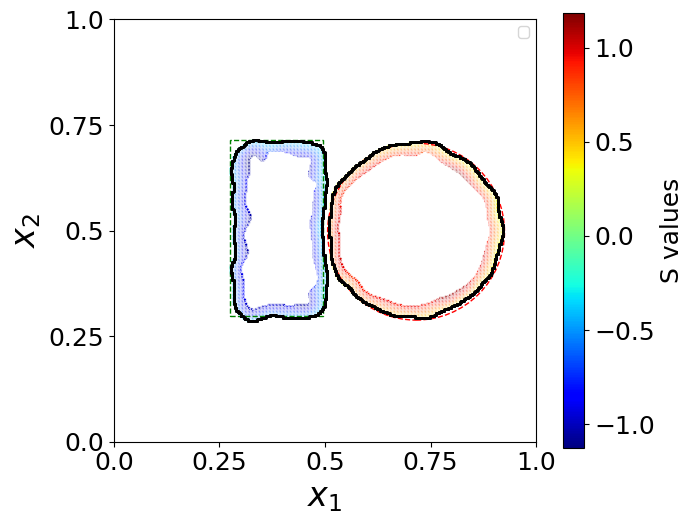

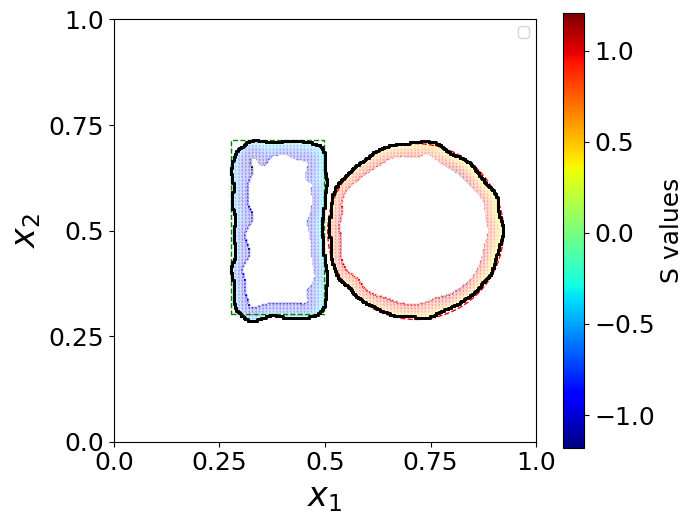

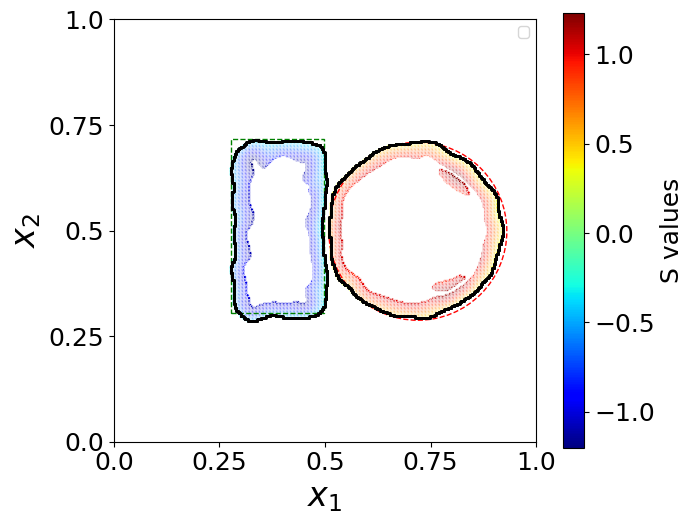

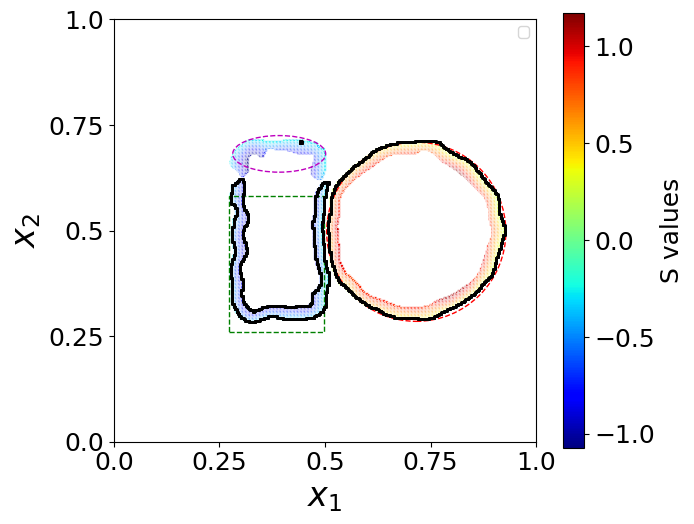

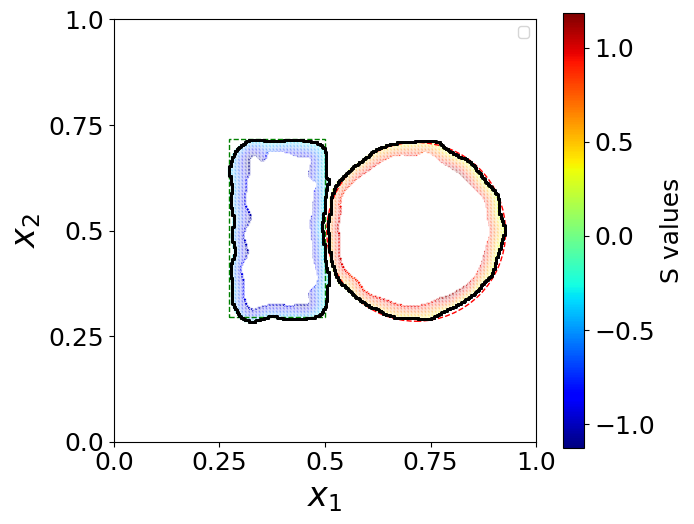

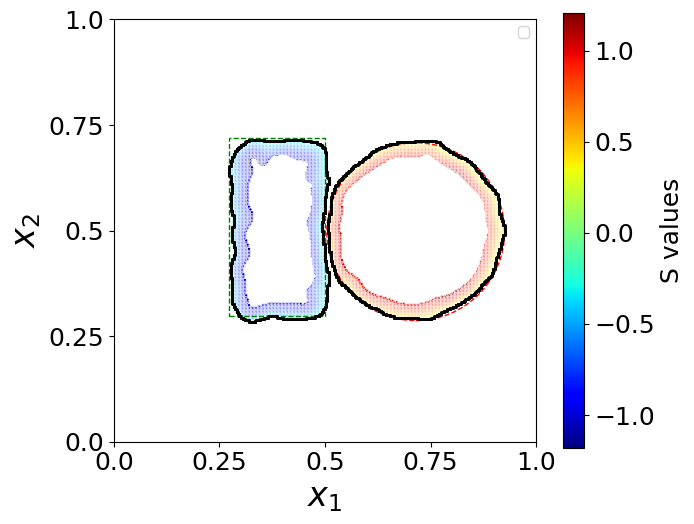

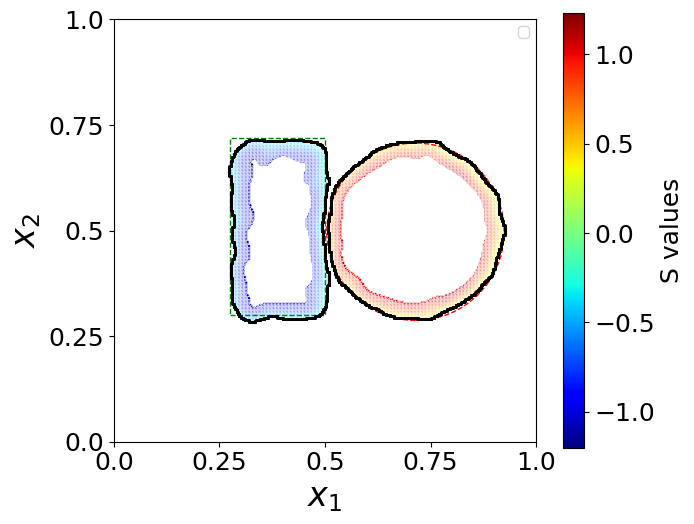

In [256]:
import Bound_detect
reload(Bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster_list=np.array([[0.02,0.02,0.02,0.02],[0.02,0.01,0.015,0.02],[0.015,0.01,0.015,0.015],[0.01,0.01,0.015,0.013]])
mini_samples_list=np.array([[20,20,20,30],[20,20,55,30],[20,20,60,40],[20,20,60,45]])

para_abs=np.array([2.5,3,4,5])
para_grad=np.array([2.5,3,4,5])
results={}
for i in range(len(eps_cluster_list)):
    for j in range(len(eps_cluster_list)):
        eps_cluster=eps_cluster_list[i][j]
        mini_samples33=mini_samples_list[i][j]
        para_abs33=para_abs[i]
        para_grad33=para_grad[j]
        results[(i,j)]=Bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs33,para_grad33,eps_cluster,mini_samples33,S_num_store[-1],output_directory="./results_ada/noise=1%_grad", output_filename="plot_{}_{}.png".format(i,j))


Number of detected clusters: 2
Cluster 0: AR=1.88
  Res_Rect=0.043 vs Res_Ellip=0.137
  -> Winner: Rectangle
  CV of S_num: 0.343
Cluster 0: Lx=0.223, Ly=0.420, AR=1.88
  -> Decision: Rectangle (Sigmoid)
  Center: (0.386, 0.500)
    W: 0.223, H: 0.420
    Rect Residual: 0.0430, Ellip Residual: 0.1371
    Aspect Ratio: 1.881
    Curvature - Std: 0.3208, Mean: 0.1053, Peak Ratio: 13.43
Cluster 1: AR=1.02
  Res_Rect=0.097 vs Res_Ellip=0.026
  -> Winner: Circle
  CV of S_num: 0.352
Cluster 1: Lx=0.407, Ly=0.413, AR=1.02
  -> Decision: Circle (Sigmoid)
  Center: (0.716, 0.497)
    Radius: 0.212
    Rect Residual: 0.0966, Ellip Residual: 0.0265
    Aspect Ratio: 1.016
    Curvature - Std: 0.3951, Mean: 0.1718, Peak Ratio: 8.23


/mnt/store/hxw-y23/AMain/Bound_detect.py:437: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


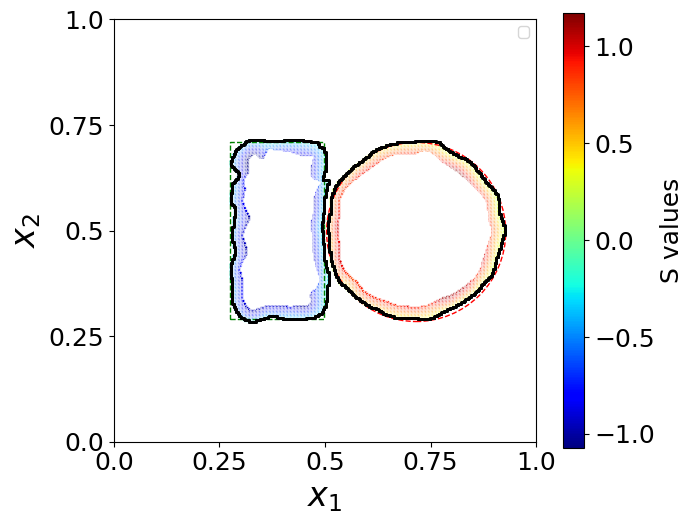

In [ ]:
results[(3,0)]=Bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,5,2.6,0.01,20,S_num_store[-1],output_directory="./Noise/noise=5%", output_filename="plot_3_0.png")

In [258]:
results

{(0,
  0): [{'cluster_id': 0,
   'shape': 'Rectangle',
   'params': {'center': array([0.38488427, 0.49699703]),
    'W': 0.2033333333333333,
    'H': 0.4033333333333334},
   'profile': 'Sigmoid'}, {'cluster_id': 1,
   'shape': 'Circle',
   'params': {'center': array([0.71368239, 0.49603249]),
    'radius': 0.20390047408206477},
   'profile': 'Sigmoid'}],
 (0,
  1): [{'cluster_id': 0,
   'shape': 'Rectangle',
   'params': {'center': array([0.38542018, 0.50500469]),
    'W': 0.2033333333333333,
    'H': 0.4},
   'profile': 'Sigmoid'}, {'cluster_id': 1,
   'shape': 'Circle',
   'params': {'center': array([0.71514142, 0.49800829]),
    'radius': 0.2031438931872445},
   'profile': 'Sigmoid'}],
 (0,
  2): [{'cluster_id': 0,
   'shape': 'Rectangle',
   'params': {'center': array([0.38739213, 0.50889907]),
    'W': 0.2033333333333333,
    'H': 0.4},
   'profile': 'Sigmoid'}, {'cluster_id': 1,
   'shape': 'Circle',
   'params': {'center': array([0.7176745, 0.4985709]),
    'radius': 0.204367007

In [ ]:
##保存results
import pickle
with open("./Noise/noise=5%/results_sensitivity.pkl", "wb") as f:
    pickle.dump(results, f)

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


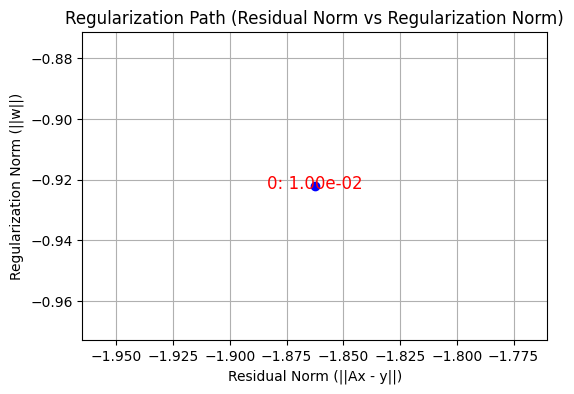

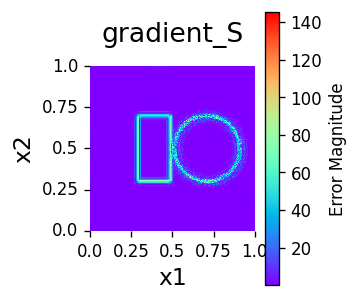

S_l_inf= 1.6490433839949348 S_L_2= 0.0671545169216034 S_l_2= 0.14868100676474827


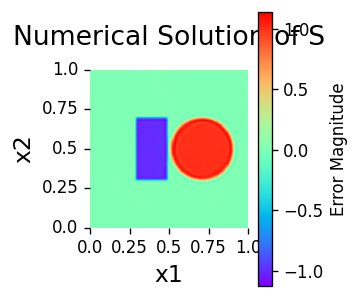

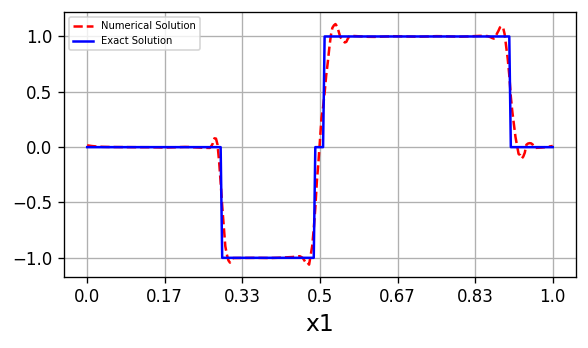

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


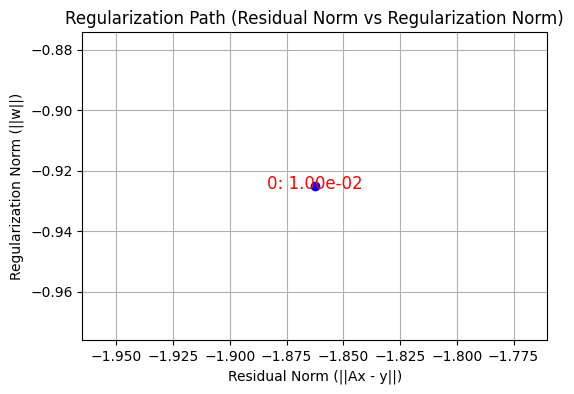

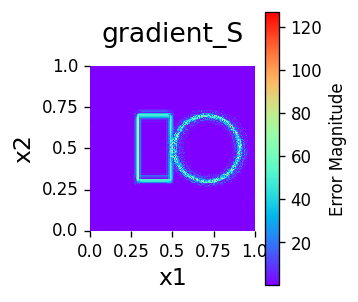

S_l_inf= 1.679350057115185 S_L_2= 0.06690677199754981 S_l_2= 0.148132496159391


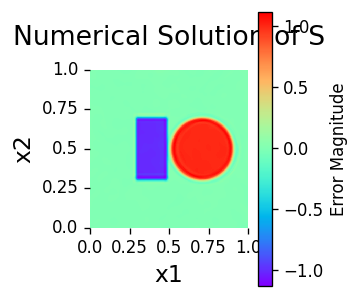

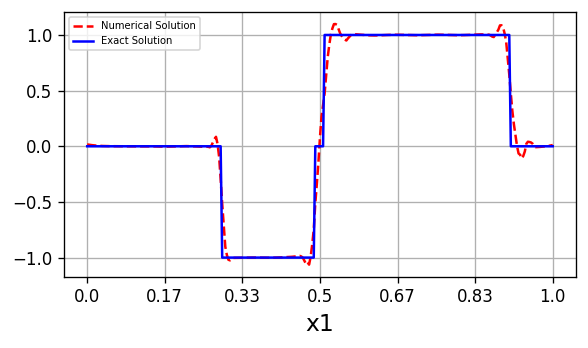

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


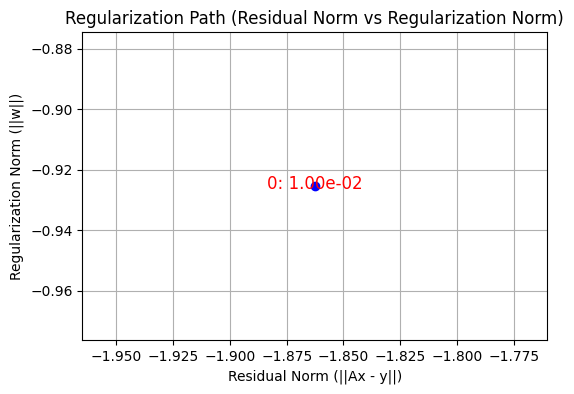

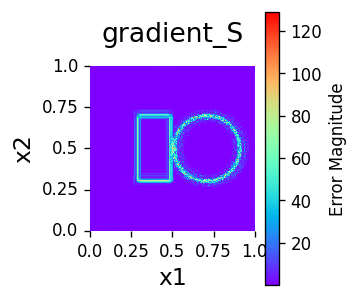

S_l_inf= 1.7003752032819688 S_L_2= 0.0678055019640161 S_l_2= 0.1501222964341789


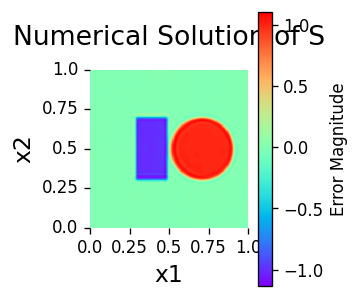

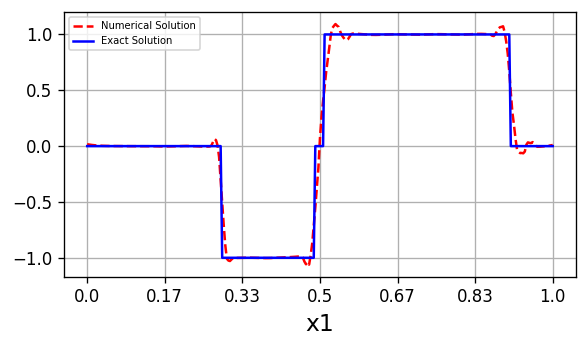

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


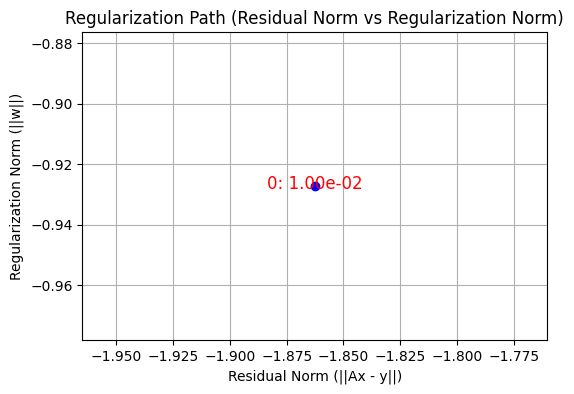

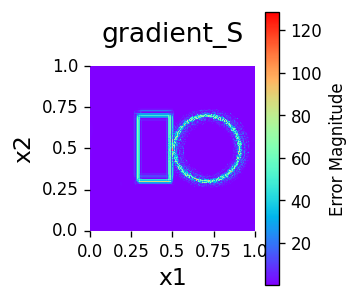

S_l_inf= 1.6842622951165631 S_L_2= 0.06737944570760603 S_l_2= 0.1491790021325399


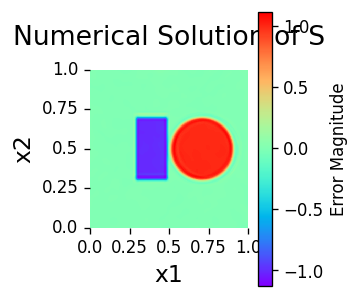

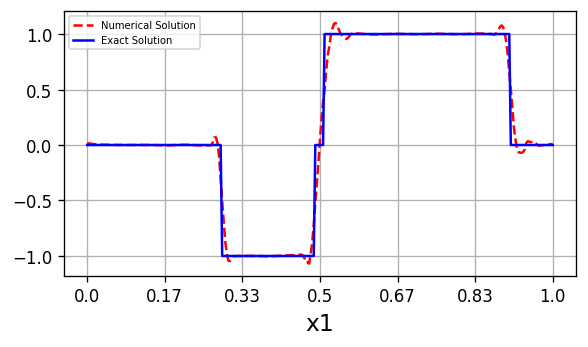

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


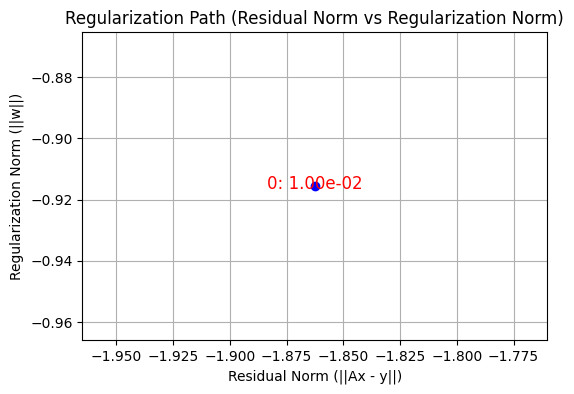

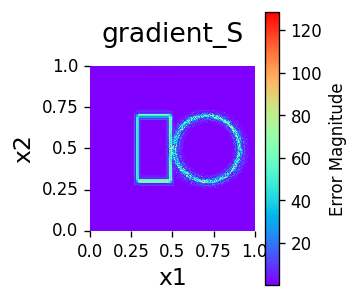

S_l_inf= 1.7060279277507437 S_L_2= 0.06735070407578685 S_l_2= 0.14911536777180245


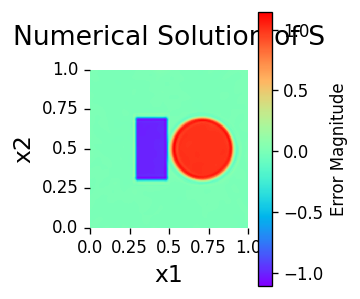

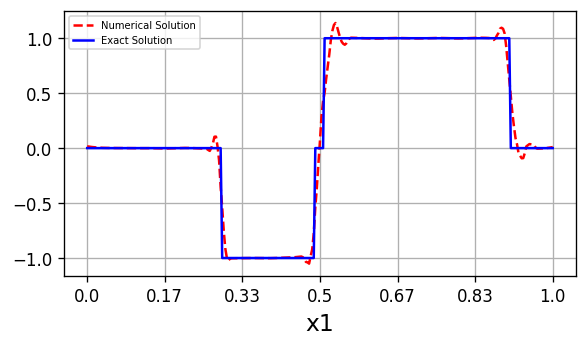

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


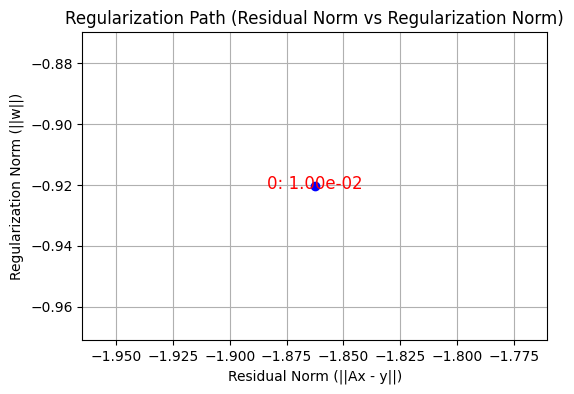

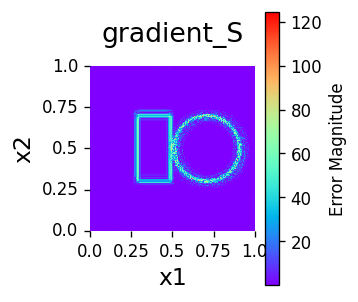

S_l_inf= 1.6594051552162294 S_L_2= 0.06741511948728718 S_l_2= 0.14925798436219825


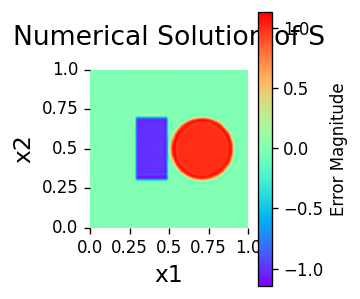

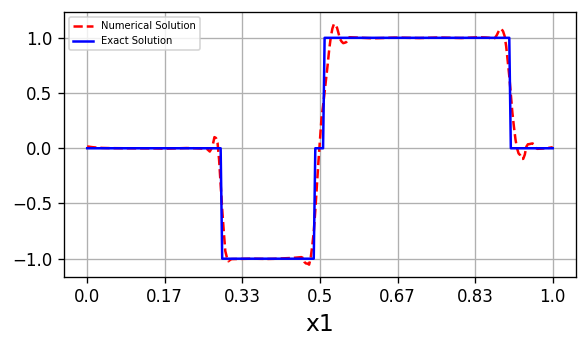

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


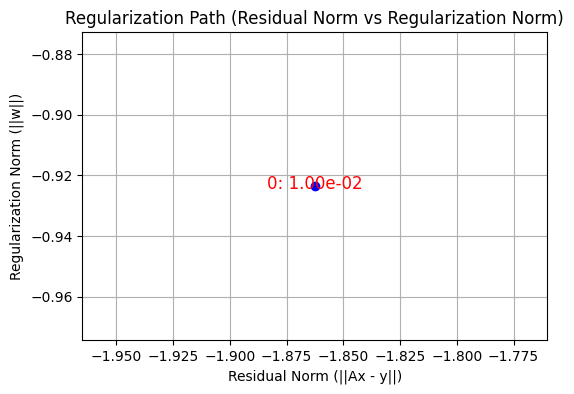

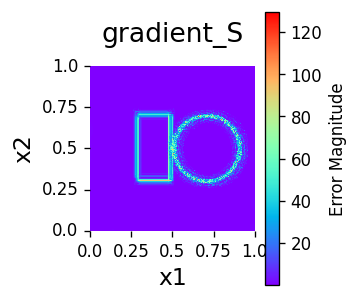

S_l_inf= 1.7237661609947168 S_L_2= 0.0686044097442706 S_l_2= 0.15189108904151902


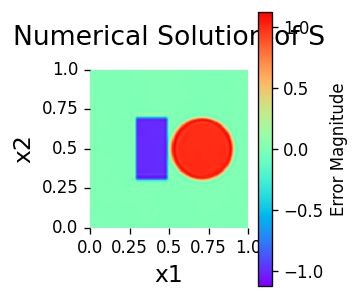

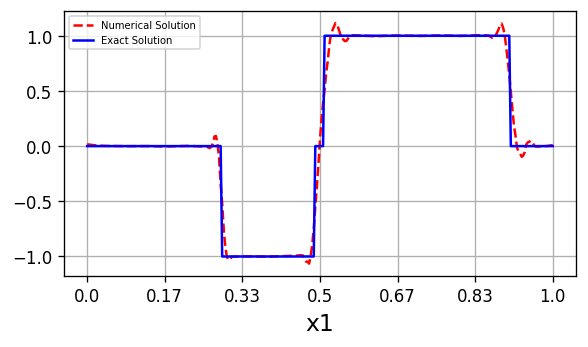

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


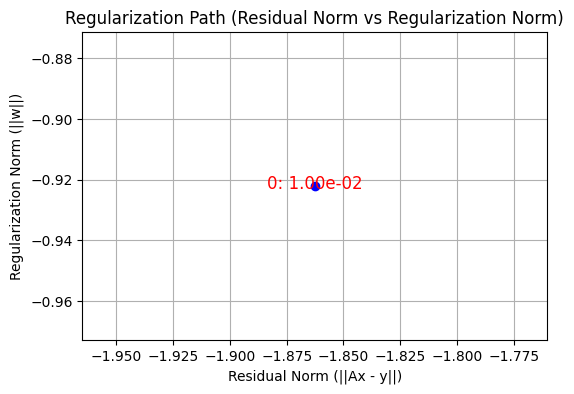

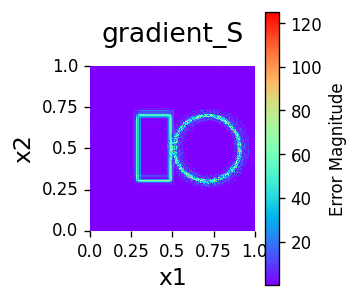

S_l_inf= 1.6724665779440668 S_L_2= 0.06751339051016088 S_l_2= 0.1494755577330814


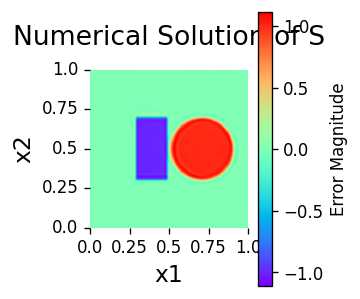

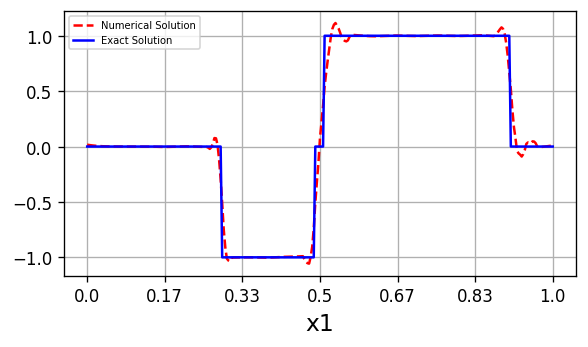

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


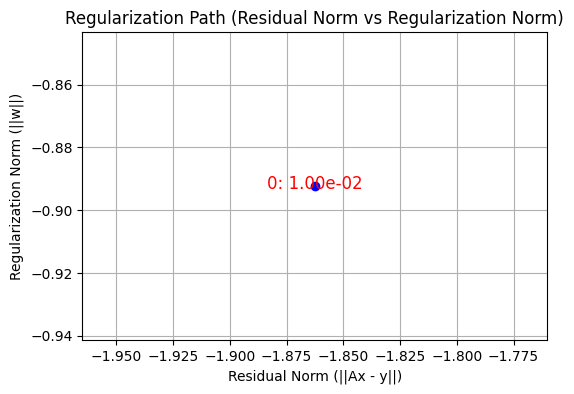

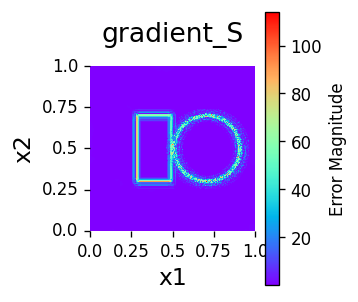

S_l_inf= 1.6207525984512483 S_L_2= 0.06709372572842158 S_l_2= 0.1485464142426212


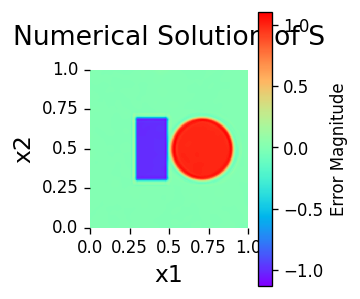

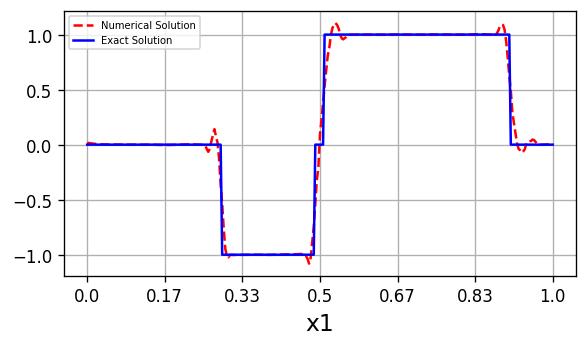

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


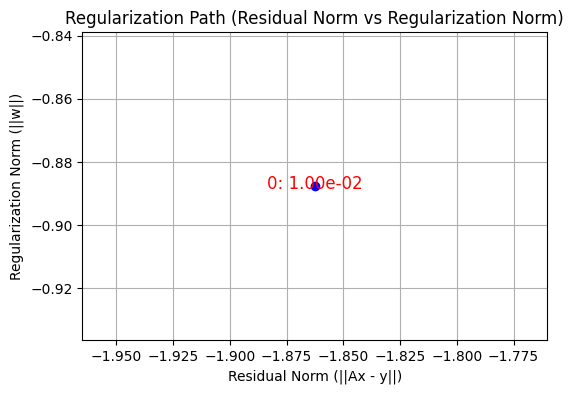

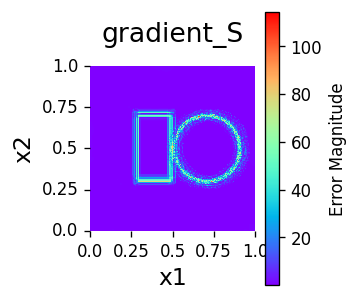

S_l_inf= 1.7182214006951255 S_L_2= 0.06939801053187723 S_l_2= 0.15364813189551496


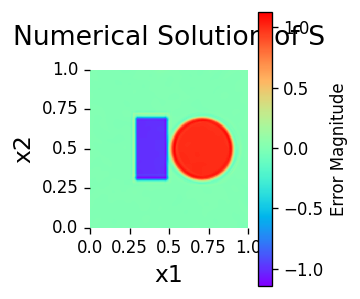

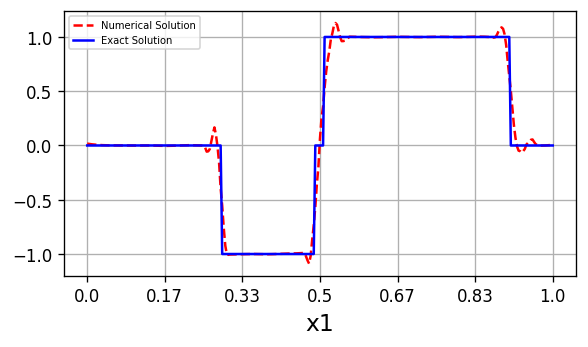

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


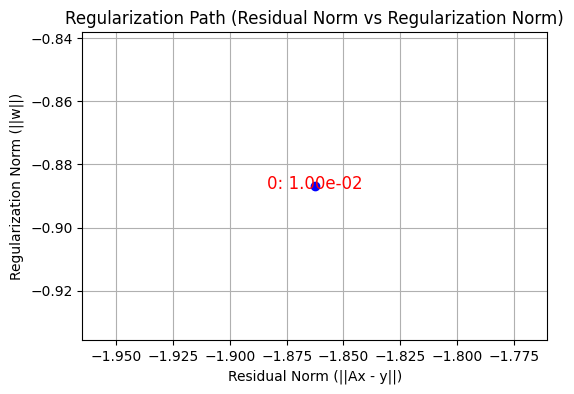

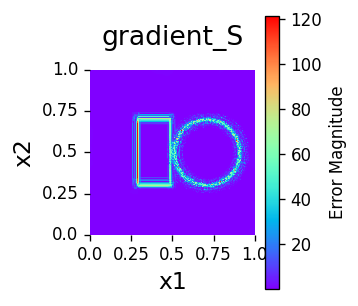

S_l_inf= 1.6031898276236614 S_L_2= 0.0678208916432072 S_l_2= 0.15015636939160323


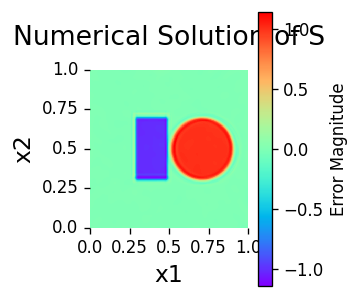

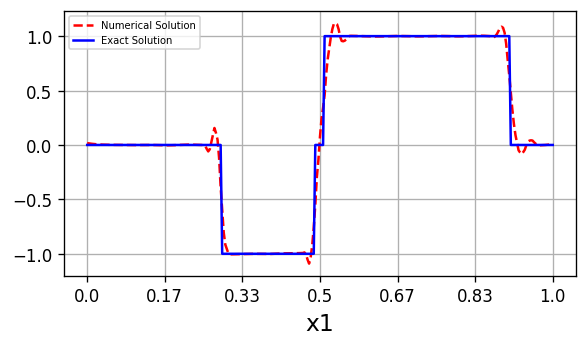

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


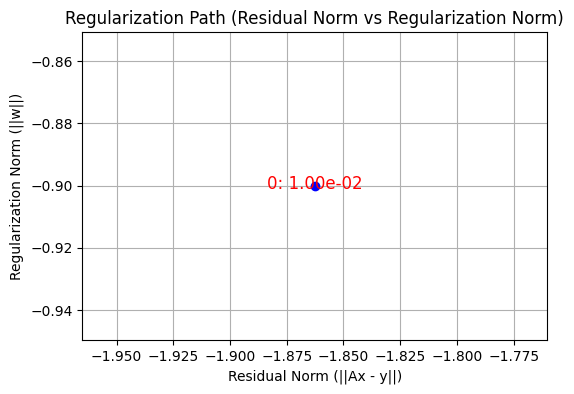

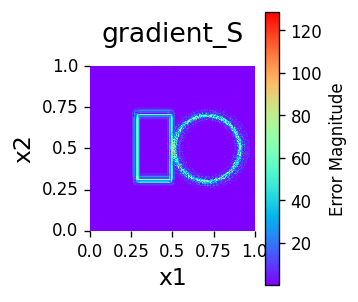

S_l_inf= 1.6592820822112748 S_L_2= 0.06821560745756598 S_l_2= 0.15103027553157802


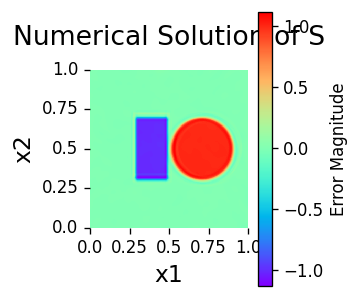

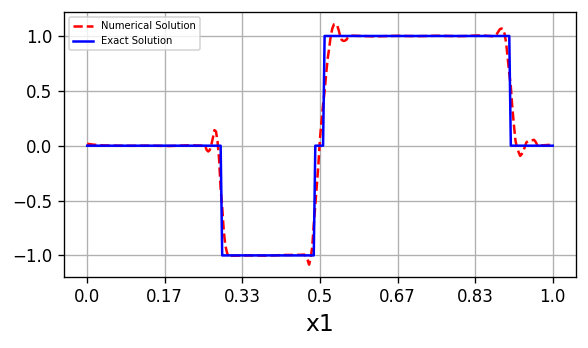

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


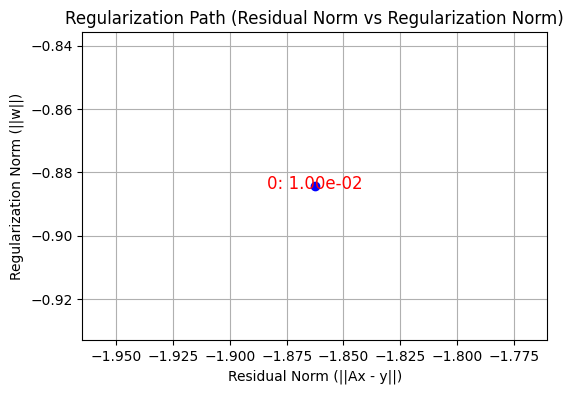

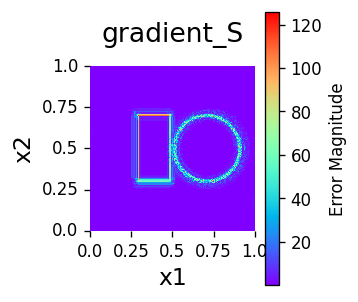

S_l_inf= 1.5768264912380265 S_L_2= 0.06793646704687947 S_l_2= 0.15041225489510995


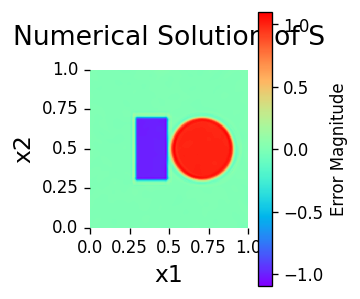

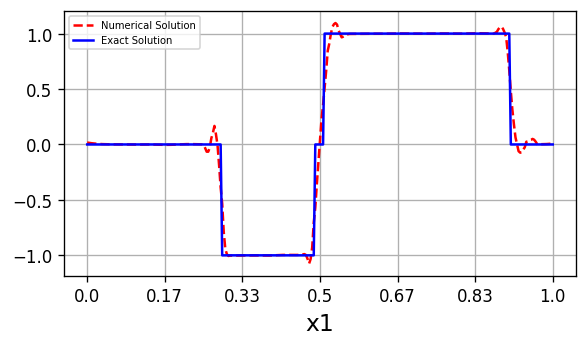

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


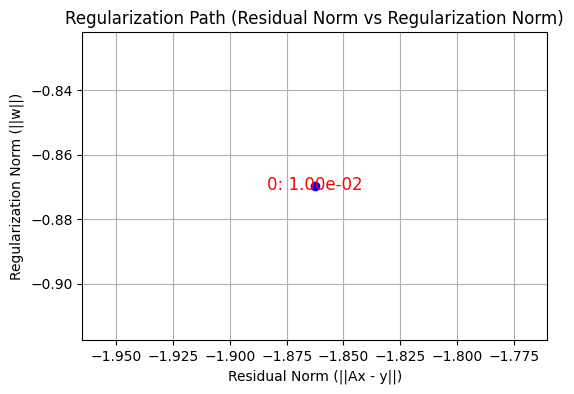

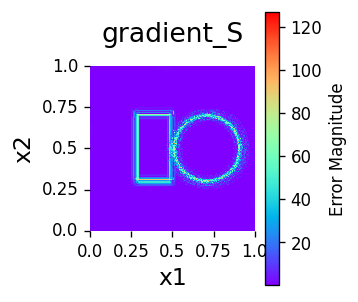

S_l_inf= 1.6204000784897512 S_L_2= 0.06742229382157046 S_l_2= 0.1492738684351244


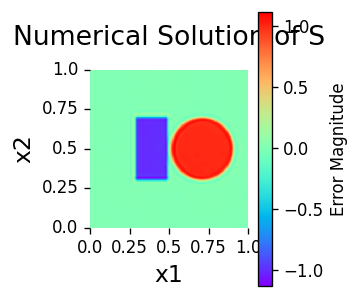

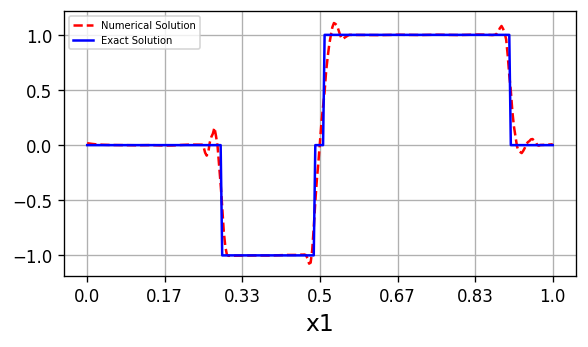

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


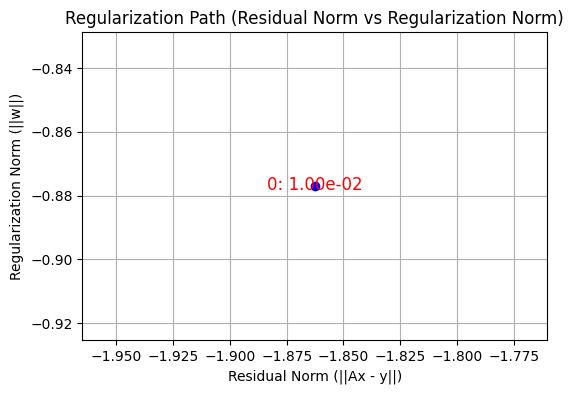

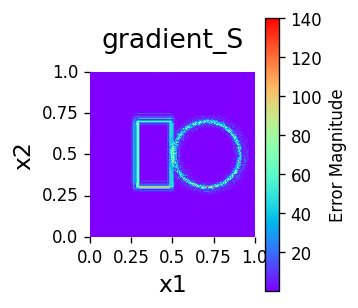

S_l_inf= 1.6519041902639664 S_L_2= 0.06747136839113385 S_l_2= 0.1493825201944357


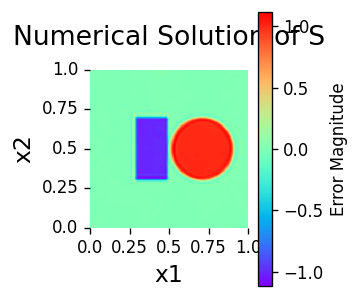

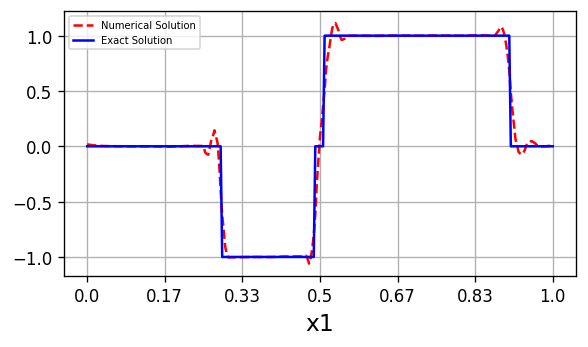

/mnt/store/hxw-y23/anaconda3/envs/inverse_source/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


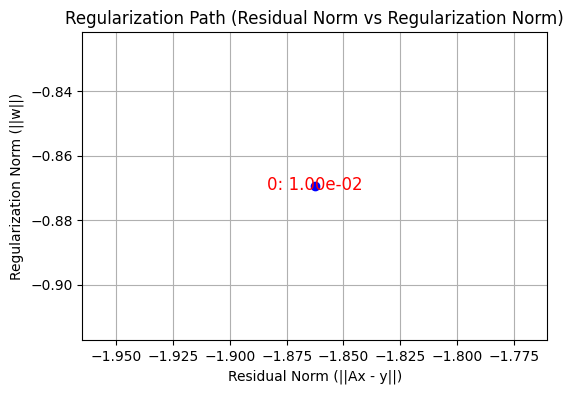

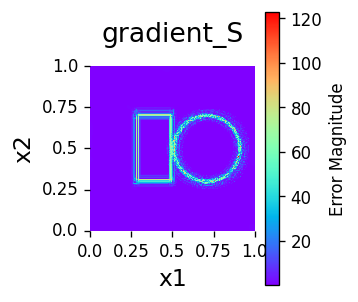

S_l_inf= 1.796506581830708 S_L_2= 0.06775041961723322 S_l_2= 0.15000034337502424


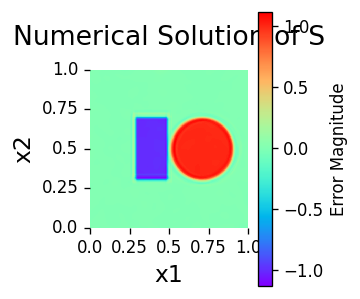

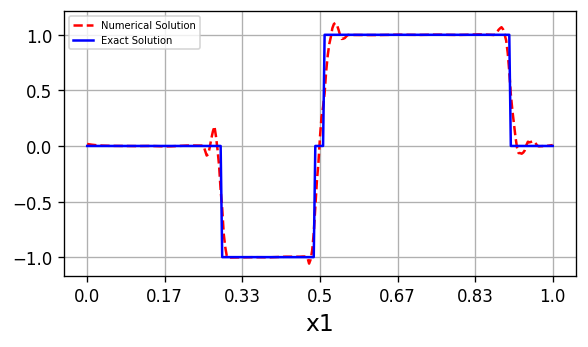

In [261]:
S_l2={}
for i in range(len(eps_cluster_list)):
    for j in range(len(eps_cluster_list)):
        center1=results[(i,j)][0]['params']['center']
        width=results[(i,j)][0]['params']['W']
        height=results[(i,j)][0]['params']['H']
        center2=results[(i,j)][1]['params']['center']
        r=results[(i,j)][1]['params']['radius']
        r_min=(1-0.1)*r
        r_max=(1+0.05)*r
        K_min=1000
        K_max=20000
        min_rec1,max_rec1,min_rec2,max_rec2=-center1[0]*(1+0.05),-center1[0]*(1-0.05),-center1[1]*(1+0.05),-center1[1]*(1-0.05)
        min_c1,max_c1,min_c2,max_c2=-center2[0]*(1+0.05),-center2[0]*(1-0.05),-center2[1]*(1+0.05),-center2[1]*(1-0.05)
        width_min,width_max=width*(1-0.1),width*(1+0.05)
        height_min,height_max=height*(1-0.1),height*(1+0.05)
        models0=models
        #models0= net_2D_fix2.pre_define(Nx, Ny,1600,3,"Tanh",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],[],[],[],[],[],[],[],[],[],[],[],[],K_min,K_max,[],device)
        models1= net_2D_fix2.pre_define(Nx, Ny,2400,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,r_min,r_max,min_c1,max_c1,min_c2,max_c2,[],[],[],[],[],[],[],[],K_min,K_max,"circle",device)
        models2= net_2D_fix2.pre_define(Nx, Ny,2400,R_m,"sigmoid",tau_x_min,tau_x_max,tau_y_min,tau_y_max,[],[],min_rec1,max_rec1,min_rec2,max_rec2,width_min,width_max,height_min,height_max,[],[],[],[],K_min,K_max,"rec",device)
        af="mix"
        sum_mat,all_g_p1,all_g_n,cells_copy1=cal_S_grad.mat_assemble2(cells_store_last,models0,models1,models2,"mix","circle","rec",kk,0,points_b,device,cupy_device)
        lamb_regu=np.logspace(-2,-2,1,endpoint=True)
        res,reg_norm,w_store=org_m.L_curve(sum_mat,F_05,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解q
        Qx,Qy=150,150
        S_test_num,S_test_true,S_l_inf1,S_l2[(i,j)],g_SS=error_general_2D.test(models0,models1,models2,[],Qx,Qy,w_store[:,:],"mix","circle","rec",True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,ana_S,1,device)

In [262]:
S_l2

{(0, 0): 0.14868100676474827,
 (0, 1): 0.148132496159391,
 (0, 2): 0.1501222964341789,
 (0, 3): 0.1491790021325399,
 (1, 0): 0.14911536777180245,
 (1, 1): 0.14925798436219825,
 (1, 2): 0.15189108904151902,
 (1, 3): 0.1494755577330814,
 (2, 0): 0.1485464142426212,
 (2, 1): 0.15364813189551496,
 (2, 2): 0.15015636939160323,
 (2, 3): 0.15103027553157802,
 (3, 0): 0.15041225489510995,
 (3, 1): 0.1492738684351244,
 (3, 2): 0.1493825201944357,
 (3, 3): 0.15000034337502424}

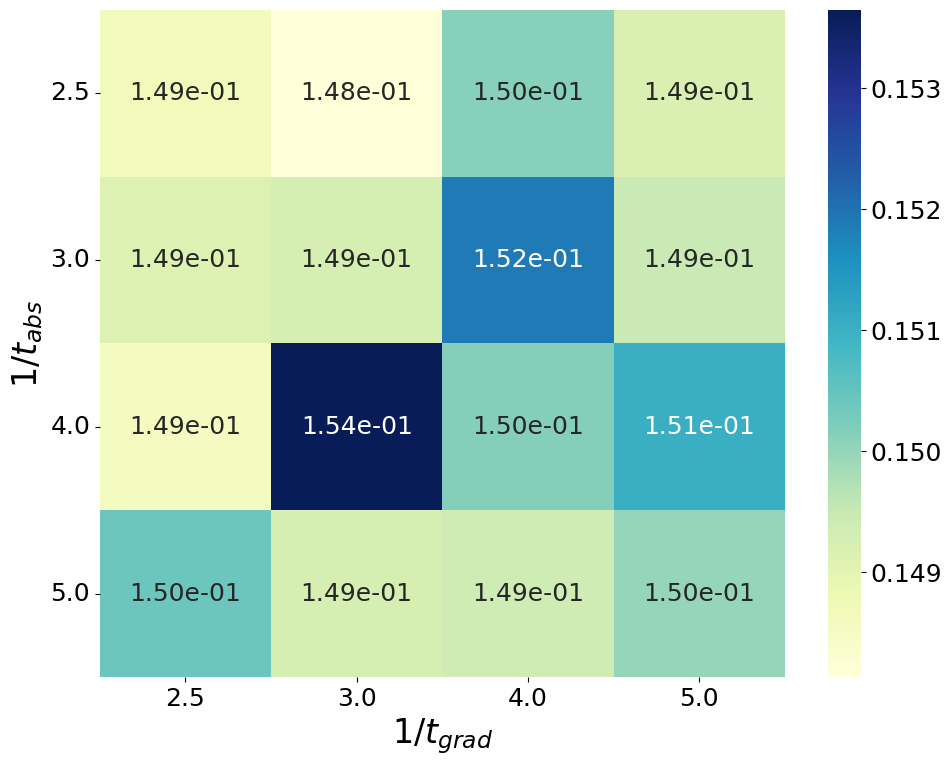

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
plt.rcParams['font.size'] = 18

# 构造二维矩阵
data = np.array([
    [S_l2[(i, j)] for j in range(len(para_grad))]
    for i in range(len(para_abs))
])

ax = sns.heatmap(
    data,
    annot=True,
    fmt='.2e',
    cmap='YlGnBu',
    xticklabels=para_grad,
    yticklabels=para_abs
)
#bar的字体大小
ax.collections[0].colorbar.ax.tick_params(labelsize=18)

plt.xlabel(r'1/$t_{grad}$', fontsize=24)
plt.ylabel(r'1/$t_{abs}$', fontsize=24)

plt.tick_params(axis='both', which='major', labelsize=18)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
#保存
plt.savefig("./Noise/noise=5%/L2_sensitivity_analysis.pdf", dpi=300)
plt.show()
